In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import models, transforms
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import io
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import pandas as pd
import noisereduce as nr
import matplotlib.cm as cm
from torch.utils.data import WeightedRandomSampler
import gc

#### Train on SER w RAVDESS

In [3]:
class AudioToSpectrogramRavdess:
    """Convert audio to Mel spectrogram image."""
    def __init__(self, sr=16000, n_mels=128, hop_length=512, n_fft=512):
        self.sr = sr
        self.n_mels = n_mels
        self.hop_length = hop_length
        self.n_fft = n_fft
    
    def convert(self, audio_path, target_size=(224, 224)):
        y, sr = librosa.load(audio_path, sr=self.sr)
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=self.n_mels,
            hop_length=self.hop_length, n_fft=self.n_fft
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        fig, ax = plt.subplots(figsize=(2.24, 2.24), dpi=100)
        ax.axis('off')
        librosa.display.specshow(mel_spec_db, sr=sr, ax=ax, cmap='magma')
        plt.tight_layout(pad=0)
        
        buf = io.BytesIO()
        plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)
        plt.close(fig)
        buf.seek(0)
        
        img = Image.open(buf).convert('RGB')
        img = img.resize(target_size, Image.LANCZOS)
        return img


class RAVDESSDataset(Dataset):
    """
    RAVDESS dataset for Speech Emotion Recognition.
    Filename format: 03-01-{emotion}-01-01-01-{actor}.wav
    Emotion: 01=neutral, 02=calm, 03=happy, 04=sad, 
                05=angry, 06=fearful, 07=disgust, 08=surprised
    """
    EMOTIONS = {
        '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
        '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
    }
    
    def __init__(self, ravdess_dir, transform=None, convert_specs=True, spec_cache_dir=None):
        self.ravdess_dir = Path(ravdess_dir)
        self.transform = transform
        self.converter = AudioToSpectrogramRavdess()
        self.spec_cache_dir = Path(spec_cache_dir) if spec_cache_dir else None
        
        # Find all audio files
        self.samples = []
        audio_files = list(self.ravdess_dir.rglob('*.wav'))
        
        for audio_path in audio_files:
            parts = audio_path.stem.split('-')
            if len(parts) >= 3:
                emotion_code = parts[2]
                if emotion_code in self.EMOTIONS:
                    emotion_idx = int(emotion_code) - 1  # 0-7
                    self.samples.append((audio_path, emotion_idx))
        
        print(f"Loaded {len(self.samples)} RAVDESS samples")
        
        if convert_specs and self.spec_cache_dir:
            self._convert_all_to_spectrograms()
    
    def _convert_all_to_spectrograms(self):
        """Pre-convert all audio to spectrograms."""
        self.spec_cache_dir.mkdir(parents=True, exist_ok=True)
        
        for audio_path, label in tqdm(self.samples, desc="Converting RAVDESS"):
            spec_path = self.spec_cache_dir / f"{audio_path.stem}.png"
            if not spec_path.exists():
                img = self.converter.convert(audio_path)
                img.save(spec_path)
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        audio_path, label = self.samples[idx]
        
        if self.spec_cache_dir:
            spec_path = self.spec_cache_dir / f"{audio_path.stem}.png"
            if spec_path.exists():
                image = Image.open(spec_path).convert('RGB')
            else:
                image = self.converter.convert(audio_path)
        else:
            image = self.converter.convert(audio_path)
        
        if self.transform:
            image = self.transform(image)
        
        return image, label


def create_ser_model(num_emotions=8, pretrained=True):
    """Create ResNet-34 for Speech Emotion Recognition."""
    model = models.resnet34(weights='IMAGENET1K_V1' if pretrained else None)
    
    # Replace classifier for 8 emotions
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_features, num_emotions)
    )
    return model


def train_ser_model(ravdess_dir, spec_cache_dir='./ravdess_specs', epochs=30):
    """
    Train SER model on RAVDESS dataset.
    Returns trained model.
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training SER on {device}")
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = RAVDESSDataset(
        ravdess_dir, 
        transform=transform, 
        convert_specs=True,
        spec_cache_dir=spec_cache_dir
    )
    
    # Split: 80% train, 20% val
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(
        dataset, [train_size, val_size],
        generator=torch.Generator().manual_seed(42)
    )
    val_dataset.dataset.transform = val_transform
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    print(f"Train: {train_size}, Val: {val_size}")
    
    model = create_ser_model(num_emotions=8, pretrained=True).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_acc = 0

    # Track history for plotting
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            _, preds = outputs.max(1)
            train_correct += preds.eq(labels).sum().item()
            train_total += labels.size(0)

        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)
        
        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "
                f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")
        
        scheduler.step(val_loss)
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), 'ser_model.pth')
            print(f"  -> Saved best SER model (acc={val_acc:.2f}%)")
    
    print(f"\nSER Training complete! Best accuracy: {best_acc:.2f}%")
    # Plot training history
    plot_training_history(history)
    
    return model, history

def plot_training_history(history):
    """Plot training and validation loss/accuracy curves."""
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()
    print("Saved plot to training_history.png")

### Transfer SER to DEEPFAKE

In [4]:
class AudioToSpectrogramClips:
    """Convert audio files to Mel spectrogram images for ResNet input."""
    
    def __init__(self, sr=16000, n_mels=128, hop_length=512, n_fft=512):
        self.sr = sr
        self.n_mels = n_mels
        self.hop_length = hop_length
        self.n_fft = n_fft
    
    def convert(self, audio_path, target_size=(224, 224)):
        """Convert single audio file to PIL Image (224x224 RGB)."""
        y, sr = librosa.load(audio_path, sr=self.sr)
        
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, 
            n_mels=self.n_mels,
            hop_length=self.hop_length,
            n_fft=self.n_fft
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Fast colormap application
        vmin, vmax = -80.0, 0.0
        normalized = np.clip(mel_spec_db, vmin, vmax)
        normalized = (normalized - vmin) / (vmax - vmin)
        
        colormap = cm.get_cmap('magma')
        colored = colormap(normalized)
        rgb_array = (colored[:, :, :3] * 255).astype(np.uint8)
        
        img = Image.fromarray(rgb_array)
        img = img.resize(target_size, Image.LANCZOS)
        return img
    
    def batch_convert(self, input_dir, output_dir, label):
        """Convert all audio files in a directory to spectrograms."""
        input_path = Path(input_dir)
        output_path = Path(output_dir) / label
        output_path.mkdir(parents=True, exist_ok=True)
        
        audio_files = (list(input_path.glob('*.wav')) + 
                        list(input_path.glob('*.flac')) + 
                        list(input_path.glob('*.mp3')))
        
        for audio_file in tqdm(audio_files, desc=f"Converting {label}"):
            img = self.convert(audio_file)
            img.save(output_path / f"{audio_file.stem}.png")
        
        print(f"Converted {len(audio_files)} files to {output_path}")

def load_ser_as_feature_extractor(ser_model_path='ser_model.pth'):
    """
    Load trained SER model and remove the classification head.
    Returns a feature extractor that outputs 512-dim vectors.
    """
    model = models.resnet34(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 8)  # Original SER head
    )

    model.load_state_dict(torch.load(ser_model_path))

    model.fc = nn.Identity()
    
    print("Loaded SER model as feature extractor (512-dim output)")
    return model


def create_deepfake_model_from_ser(ser_model_path='ser_model.pth', freeze_backbone=True):
    """
    Create deepfake detector using SER backbone.
    
    Args:
        ser_model_path: Path to trained SER model
        freeze_backbone: If True, only train the new classifier
    """
    # Load full SER model
    model = models.resnet34(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 8)
    )
    model.load_state_dict(torch.load(ser_model_path))
    
    # Freeze backbone if specified
    if freeze_backbone:
        for name, param in model.named_parameters():
            if 'fc' not in name:
                param.requires_grad = False
    
    # Replace classifier head for binary classification
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 2)
    )
    
    for param in model.fc.parameters():
        param.requires_grad = True
    
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Deepfake model created from SER backbone")
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
    
    return model


class DeepfakeSpectrogramDataset(Dataset):
    """Dataset for deepfake spectrograms (same as before)."""
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []
        
        real_dir = self.root_dir / 'real'
        if real_dir.exists():
            for img_path in real_dir.glob('*.png'):
                self.samples.append((img_path, 0))
        
        fake_dir = self.root_dir / 'fake'
        if fake_dir.exists():
            for img_path in fake_dir.glob('*.png'):
                self.samples.append((img_path, 1))
        
        print(f"Loaded {len(self.samples)} deepfake samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

def train_deepfake_from_ser(
    deepfake_spec_dir='./spectrograms',
    ser_model_path='ser_model.pth',
    freeze_backbone=True,
    unfreeze_from=None,
    epochs=30,
    lr=1e-4,
    patience=10
):
    """Train deepfake detector using SER backbone."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nTraining Deepfake Detector on {device}")
    print(f"Using SER backbone from: {ser_model_path}")
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    dataset = DeepfakeSpectrogramDataset(deepfake_spec_dir, transform=transform)
    
    total = len(dataset)
    train_size = int(0.7 * total)
    val_size = int(0.15 * total)
    test_size = total - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )
    val_dataset.dataset.transform = val_transform
    test_dataset.dataset.transform = val_transform
    
    print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")
    
    train_labels = [dataset.samples[i][1] for i in train_dataset.indices]
    train_real_count = train_labels.count(0)
    train_fake_count = train_labels.count(1)

    print(f"Train set balance:")
    print(f"  Real: {train_real_count} ({100*train_real_count/len(train_labels):.1f}%)")
    print(f"  Fake: {train_fake_count} ({100*train_fake_count/len(train_labels):.1f}%)")

    # Weighted Sampler
    class_counts = [train_real_count, train_fake_count]
    class_weights = [1.0 / count for count in class_counts]  # Inverse frequency
    sample_weights = [class_weights[label] for label in train_labels]
    
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    
    train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

    test_labels = [dataset.samples[i][1] for i in test_dataset.indices]
    test_real_count = test_labels.count(0)
    test_fake_count = test_labels.count(1)

    print(f"Test set balance:")
    print(f"  Real: {test_real_count} ({100*test_real_count/len(test_labels):.1f}%)")
    print(f"  Fake: {test_fake_count} ({100*test_fake_count/len(test_labels):.1f}%)")
    
    model = create_deepfake_model_from_ser(ser_model_path, freeze_backbone).to(device)

    if unfreeze_from:
        unfreeze = False
        for name, param in model.named_parameters():
            if unfreeze_from in name:
                unfreeze = True
            if unfreeze:
                param.requires_grad = True
        
        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        total_params = sum(p.numel() for p in model.parameters())
        print(f"Unfroze from {unfreeze_from}: {trainable:,} / {total_params:,} params trainable ({100*trainable/total_params:.1f}%)")
    
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=0.05
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    best_acc = 0
    epochs_no_improve = 0

    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        train_real_correct = 0
        train_real_total = 0
        train_fake_correct = 0
        train_fake_total = 0

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, preds = outputs.max(1)
            train_correct += preds.eq(labels).sum().item()
            train_total += labels.size(0)

            real_mask = labels == 0
            fake_mask = labels == 1
            train_real_correct += preds[real_mask].eq(labels[real_mask]).sum().item()
            train_real_total += real_mask.sum().item()
            train_fake_correct += preds[fake_mask].eq(labels[fake_mask]).sum().item()
            train_fake_total += fake_mask.sum().item()

        train_loss /= len(train_loader)
        train_acc = 100 * train_correct / train_total
        
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0

        val_real_correct = 0
        val_real_total = 0
        val_fake_correct = 0
        val_fake_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, preds = outputs.max(1)
                val_correct += preds.eq(labels).sum().item()
                val_total += labels.size(0)

                # Per-class tracking
                real_mask = labels == 0
                fake_mask = labels == 1
                val_real_correct += preds[real_mask].eq(labels[real_mask]).sum().item()
                val_real_total += real_mask.sum().item()
                val_fake_correct += preds[fake_mask].eq(labels[fake_mask]).sum().item()
                val_fake_total += fake_mask.sum().item()

        val_loss /= len(val_loader)
        val_acc = 100 * val_correct / val_total
        val_real_acc = 100 * val_real_correct / val_real_total if val_real_total > 0 else 0
        val_fake_acc = 100 * val_fake_correct / val_fake_total if val_fake_total > 0 else 0

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.2f}%, "
                f"Val Loss={val_loss:.4f}, Val Acc={val_acc:.2f}%")
        print(f"  -> Val REAL Acc: {val_real_acc:.1f}% ({val_real_correct}/{val_real_total}), "
                f"Val FAKE Acc: {val_fake_acc:.1f}% ({val_fake_correct}/{val_fake_total})")
        
        scheduler.step(val_loss)
        
        if val_acc > best_acc:
            best_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'deepfake_from_ser.pth')
            print(f"  -> Saved best model (acc={val_acc:.2f}%)")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    plot_training_history(history)

    model.load_state_dict(torch.load('deepfake_from_ser.pth'))
    model.eval()
    correct, total = 0, 0

    all_labels = []
    all_preds = []

    test_real_correct = 0
    test_real_total = 0
    test_fake_correct = 0
    test_fake_total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            real_mask = labels == 0
            fake_mask = labels == 1
            test_real_correct += preds[real_mask].eq(labels[real_mask]).sum().item()
            test_real_total += real_mask.sum().item()
            test_fake_correct += preds[fake_mask].eq(labels[fake_mask]).sum().item()
            test_fake_total += fake_mask.sum().item()
    
    test_acc = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='binary')
    test_precision = precision_score(all_labels, all_preds, average='binary')
    test_recall = recall_score(all_labels, all_preds, average='binary')
    
    print(f"\n{'='*50}")
    print(f"FINAL TEST RESULTS")
    print(f"{'='*50}")
    print(f"Overall Accuracy: {test_acc:.2f}%")
    print(f"F1 Score: {f1:.2f}%")
    print(f"Precision: {test_precision:.2f}%")
    print(f"Recall: {test_recall:.2f}%")
    print(f"REAL Accuracy: {100*test_real_correct/test_real_total:.2f}% ({test_real_correct}/{test_real_total})")
    print(f"FAKE Accuracy: {100*test_fake_correct/test_fake_total:.2f}% ({test_fake_correct}/{test_fake_total})")
    print(f"{'='*50}")

    print(f"\n{'='*50}")
    print("CLASSIFICATION REPORT")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=['REAL', 'FAKE']))
    
    return model, history

def plot_training_history(history):
    """Plot training and validation loss/accuracy curves."""
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss plot
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150)
    plt.show()
    print("Saved plot to training_history.png")

## Main full pipeline

#### Train SER model on RAVDESS

In [ ]:
if __name__ == "__main__":
    
    RAVDESS_DIR = './Ravdess data'  # Path to RAVDESS dataset
    
    print("="*50)
    print("STEP 1: Training SER Model on RAVDESS")
    print("="*50)
    
    # # Uncomment to train SER
    # ser_model = train_ser_model(RAVDESS_DIR, spec_cache_dir='./ravdess_specs', epochs=30)


STEP 1: Training SER Model on RAVDESS


### Trf to Deepfake detection


STEP 2: Training Deepfake Detector from SER

Training Deepfake Detector on cuda
Using SER backbone from: ser_model.pth
Loaded 7651 deepfake samples
Train: 5355, Val: 1147, Test: 1149
Train set balance:
  Real: 1702 (31.8%)
  Fake: 3653 (68.2%)
Test set balance:
  Real: 360 (31.3%)
  Fake: 789 (68.7%)
Deepfake model created from SER backbone
Trainable params: 21,285,698 / 21,285,698 (100.0%)
Unfroze from layer3: 21,285,698 / 21,285,698 params trainable (100.0%)


Epoch 1: 100%|██████████| 168/168 [00:35<00:00,  4.80it/s]


Epoch 1: Train Loss=0.4063, Train Acc=87.43%, Val Loss=0.3260, Val Acc=93.64%
  -> Val REAL Acc: 89.4% (321/359), Val FAKE Acc: 95.6% (753/788)
  -> Saved best model (acc=93.64%)


Epoch 2: 100%|██████████| 168/168 [00:34<00:00,  4.89it/s]


Epoch 2: Train Loss=0.2978, Train Acc=95.42%, Val Loss=0.2776, Val Acc=96.08%
  -> Val REAL Acc: 94.7% (340/359), Val FAKE Acc: 96.7% (762/788)
  -> Saved best model (acc=96.08%)


...

Epoch 15: Train Loss=0.2246, Train Acc=98.94%, Val Loss=0.2564, Val Acc=96.60%
  -> Val REAL Acc: 94.7% (340/359), Val FAKE Acc: 97.5% (768/788)


Epoch 16: 100%|██████████| 168/168 [00:36<00:00,  4.55it/s]


Epoch 16: Train Loss=0.2237, Train Acc=98.86%, Val Loss=0.2592, Val Acc=97.04%
  -> Val REAL Acc: 93.3% (335/359), Val FAKE Acc: 98.7% (778/788)


Epoch 17: 100%|██████████| 168/168 [00:37<00:00,  4.43it/s]


Epoch 17: Train Loss=0.2204, Train Acc=99.18%, Val Loss=0.2587, Val Acc=96.77%
  -> Val REAL Acc: 93.3% (335/359), Val FAKE Acc: 98.4% (775/788)
Early stopping at epoch 17


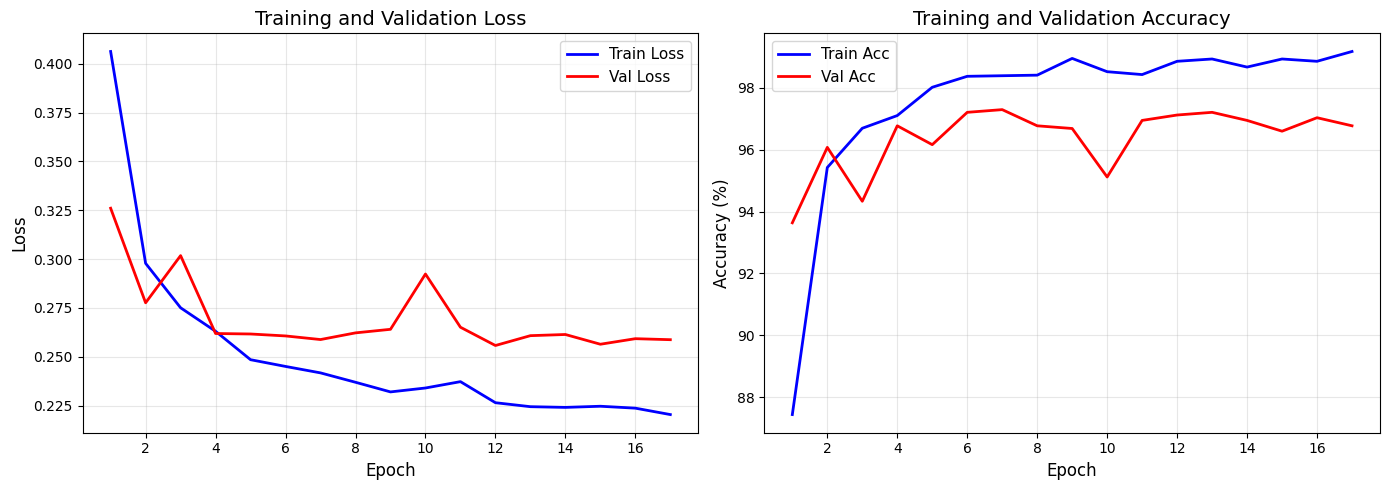

Saved plot to training_history.png

FINAL TEST RESULTS
Overall Accuracy: 96.34%
F1 Score: 0.97%
Precision: 0.96%
Recall: 0.98%
REAL Accuracy: 91.94% (331/360)
FAKE Accuracy: 98.35% (776/789)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        REAL       0.96      0.92      0.94       360
        FAKE       0.96      0.98      0.97       789

    accuracy                           0.96      1149
   macro avg       0.96      0.95      0.96      1149
weighted avg       0.96      0.96      0.96      1149



In [ ]:

if __name__ == "__main__":

    AUDIO_ROOT = '10s_clips/AUDIO_CLEAN' # Path to your 10s audio clips (REAL and FAKE folders inside)
    SPECTROGRAM_ROOT = './spectrograms_10s'  # Creates new folder for your deepfake spectrograms

    converter = AudioToSpectrogramClips(sr=16000, n_mels=128, hop_length=512, n_fft=512)
    # converter.batch_convert(f'{AUDIO_ROOT}/REAL', SPECTROGRAM_ROOT, 'real')
    # converter.batch_convert(f'{AUDIO_ROOT}/FAKE', SPECTROGRAM_ROOT, 'fake')

    converter.batch_convert(f'{AUDIO_ROOT}/human', SPECTROGRAM_ROOT, 'real')
    converter.batch_convert(f'{AUDIO_ROOT}/nonhuman', SPECTROGRAM_ROOT, 'fake')

    print("\n" + "="*50)
    print("STEP 2: Training Deepfake Detector from SER")
    print("="*50)

    # Train deepfake detector using SER backbone:
    deepfake_model = train_deepfake_from_ser(
        deepfake_spec_dir=SPECTROGRAM_ROOT,
        ser_model_path='ser_model.pth',  
        freeze_backbone=False,
        unfreeze_from='layer3',
        lr=5e-5,
        epochs=30
    )
    

### Testing with New Data

In [8]:
def segment_to_image_fast(mel_spec_db, target_size=(224, 224)):
    """Fast colormap application — matches training preprocessing."""
    vmin, vmax = -80.0, 0.0
    normalized = np.clip(mel_spec_db, vmin, vmax)
    normalized = (normalized - vmin) / (vmax - vmin)
    
    colormap = cm.get_cmap('magma')
    colored = colormap(normalized)
    rgb_array = (colored[:, :, :3] * 255).astype(np.uint8)
    
    img = Image.fromarray(rgb_array)
    img = img.resize(target_size, Image.LANCZOS)
    return img


In [9]:
def predict_audio_folder(
    audio_folder,
    model_path='deepfake_from_ser.pth',
    output_csv='predictions.csv',
    segment_length=10,
    sample_rate=16000,
    n_mels=128,
    n_fft=512,
    hop_length=512,
    fake_threshold=0.5,
    denoise=False
):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Load model
    model = models.resnet34(weights=None)
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(512, 2)
    )
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    print(f"Loaded model from {model_path}")
    
    # Transform (same as training)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # Find all audio files
    audio_path = Path(audio_folder)
    audio_extensions = {'.mp3', '.wav', '.flac'}
    audio_files = [f for f in audio_path.iterdir() if f.suffix.lower() in audio_extensions]
    
    if len(audio_files) == 0:
        print(f"No audio files found in {audio_folder}")
        return pd.DataFrame()
    
    print(f"Found {len(audio_files)} audio files to predict")
    
    results = []
    
    for audio_file in tqdm(audio_files, desc="Predicting"):
        try:
            # Load full audio
            y, sr = librosa.load(str(audio_file), sr=sample_rate, mono=True)
            
            if denoise:
                y = nr.reduce_noise(y=y, sr=sr)

            # Segment into 10s clips
            segment_samples = segment_length * sample_rate
            segments = []
            for start in range(0, len(y), segment_samples):
                end = min(start + segment_samples, len(y))
                segment = y[start:end]
                if len(segment) < segment_samples:
                    segment = np.pad(segment, (0, segment_samples - len(segment)), mode='constant')
                segments.append(segment)
            
            # Predict each segment
            segment_predictions = []
            
            with torch.no_grad():
                for segment in segments:
                    # Create spectrogram
                    mel_spec = librosa.feature.melspectrogram(
                        y=segment, sr=sample_rate,
                        n_mels=n_mels, hop_length=hop_length, n_fft=n_fft
                    )
                    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
                    
                    # Fast image conversion (matches training)
                    img = segment_to_image_fast(mel_spec_db)
                    
                    # Transform and predict
                    img_tensor = transform(img).unsqueeze(0).to(device)
                    outputs = model(img_tensor)
                    probs = torch.softmax(outputs, dim=1)
                    
                    pred = 1 if probs[0, 1] >= 0.5 else 0
                    segment_predictions.append(pred)
            
            # Aggregate: majority voting
            fake_count = sum(segment_predictions)
            fake_ratio = fake_count / len(segment_predictions)
            final_prediction = 1 if fake_ratio >= fake_threshold else 0
            
            results.append({
                'filename': audio_file.name,
                'prediction': 'FAKE' if final_prediction == 1 else 'REAL',
                'confidence': fake_ratio if final_prediction == 1 else (1 - fake_ratio),
                'num_segments': len(segment_predictions),
                'fake_segments': fake_count,
                'segment_predictions': segment_predictions
            })
            
        except Exception as e:
            print(f"Error processing {audio_file.name}: {e}")
            results.append({
                'filename': audio_file.name,
                'prediction': 'ERROR',
                'confidence': 0,
                'num_segments': 0,
                'fake_segments': 0,
                'segment_predictions': []
            })
    
    # Create DataFrame
    df = pd.DataFrame(results)
    
    # Print summary
    print(f"\n{'='*50}")
    print("PREDICTION SUMMARY")
    print(f"{'='*50}")
    print(f"Total files: {len(df)}")
    print(f"Predicted REAL: {(df['prediction'] == 'REAL').sum()}")
    print(f"Predicted FAKE: {(df['prediction'] == 'FAKE').sum()}")
    print(f"Errors: {(df['prediction'] == 'ERROR').sum()}")
    
    # Print individual results
    print(f"\n{'='*50}")
    print("INDIVIDUAL PREDICTIONS")
    print(f"{'='*50}")
    for _, row in df.iterrows():
        safe_filename = row['filename'].encode('ascii', errors='replace').decode('ascii')
        print(f"{safe_filename}: {row['prediction']} "
                f"({row['confidence']:.1%}, {row['fake_segments']}/{row['num_segments']} fake segments)")
    
    # Save to CSV
    df.to_csv(output_csv, index=False)
    print(f"\nSaved predictions to {output_csv}")
    
    return df

### See test results

#### Entire Dataset

In [ ]:
results = predict_audio_folder(
    audio_folder='10s_clips/AUDIO_CLEAN/human',
    model_path='best_weights/BEST_deepfake_from_ser.pth',
    output_csv='predictions.csv',
    fake_threshold=0.5,
    # denoise=False
)

Using device: cuda
Loaded model from deepfake_from_ser.pth
Found 2835 audio files to predict


Predicting:   0%|          | 0/2835 [00:00<?, ?it/s]C:\Users\bryan\AppData\Local\Temp\ipykernel_21700\932423872.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('magma')
Predicting: 100%|██████████| 2835/2835 [01:43<00:00, 27.27it/s]



PREDICTION SUMMARY
Total files: 2835
Predicted REAL: 1
Predicted FAKE: 2834
Errors: 0

INDIVIDUAL PREDICTIONS
biden-to-linus_part1_extended_1.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_2.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_3.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_4.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_5.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_6.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_7.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_8.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part1_extended_9.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part2_extended_1.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part2_extended_2.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part2_extended_3.mp3: FAKE (100.0%, 1/1 fake segments)
biden-to-linus_part2_extended_4.mp3: FAKE (100.0%

#### Unseen Data

In [ ]:
# results = predict_audio_folder(
#     audio_folder='Test Folder',
#     model_path='best_weights/BEST_deepfake_from_ser.pth',
#     output_csv='predictions.csv',
#     fake_threshold=0.5,
#     denoise=False
# )

Using device: cuda
Loaded model from deepfake_from_ser.pth
Found 20 audio files to predict


Predicting:   0%|          | 0/20 [00:00<?, ?it/s]C:\Users\bryan\AppData\Local\Temp\ipykernel_21700\932423872.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('magma')
Predicting: 100%|██████████| 20/20 [00:02<00:00,  9.73it/s]


PREDICTION SUMMARY
Total files: 20
Predicted REAL: 10
Predicted FAKE: 10
Errors: 0

INDIVIDUAL PREDICTIONS
00001.wav: REAL (100.0%, 0/1 fake segments)
00003.wav: FAKE (100.0%, 1/1 fake segments)
00004.wav: FAKE (50.0%, 1/2 fake segments)
00005.wav: REAL (100.0%, 0/1 fake segments)
00006.wav: REAL (100.0%, 0/1 fake segments)
00007.wav: REAL (100.0%, 0/1 fake segments)
00008.wav: FAKE (100.0%, 1/1 fake segments)
00009.wav: REAL (100.0%, 0/1 fake segments)
clean_Ranking_the_Funniest_AI_Creations.mp3: FAKE (75.0%, 3/4 fake segments)
Clean_What_If_You_Brought_a_Smartphone_to_Ancient_Greece_Socrates_vs_Google.mp3: FAKE (100.0%, 6/6 fake segments)
clean_What_If_You_Were_Raised_by_Socrates.mp3: FAKE (85.7%, 6/7 fake segments)
examples_favorite_riding_hood.mp3: REAL (92.0%, 2/25 fake segments)
p234_019.wav: FAKE (100.0%, 1/1 fake segments)
p254_003.wav: REAL (100.0%, 0/1 fake segments)
p262_005.wav: FAKE (100.0%, 1/1 fake segments)
p271_232.wav: REAL (100.0%, 0/1 fake segments)
Ranking the Fun